In [1]:
import os
import utils
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [2]:
load_dotenv()
# f"postgres+psycopg2://{[user]}:{[pass]}@{[host}:{[port]}/{[dbname]}"
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST')}:{os.getenv('POSTGRES_PORT')}/{os.getenv('POSTGRES_DB')}"
)

In [ ]:
start_time='08:30:00'
end_time='15:00:00'
query_min = "SELECT * FROM silver.es_bars WHERE bar_time BETWEEN %(start)s AND %(end)s ORDER BY bar_date, bar_time"
query_legs = "SELECT * FROM gold.es_legs WHERE time_start BETWEEN %(start)s AND %(end)s OR time_end BETWEEN %(start)s AND %(end)s ORDER BY date, time_start"
df_min = pd.read_sql(query_min,engine, params={"start": start_time, "end": end_time})
df_legs = pd.read_sql(query_legs,engine, params={"start": start_time, "end": end_time})

In [4]:
utils.create_time_bucket(df_legs,'time_start','30')
utils.create_time_bucket(df_legs,'time_start','15')
utils.create_time_bucket(df_legs,'time_start','5')

df_legs = utils.add_winsorized_col(df_legs,'volume')

df_legs['magnitude'] = np.where(
    df_legs['trend'] == "UP",
    np.floor(df_legs['high'] - df_legs['open']),
    np.floor(df_legs['open'] - df_legs['close'])
)
df_legs = utils.add_winsorized_col(df_legs,'magnitude')

df_legs['drawdown'] = np.where(
    df_legs['trend'] == "DOWN",
    df_legs['high'] - df_legs['open'],
    df_legs['open'] - df_legs['low']
)
df_legs = utils.add_winsorized_col(df_legs,'drawdown')

df_legs['price_movement'] = df_legs['high'] - df_legs['low']
df_legs = utils.add_winsorized_col(df_legs,'price_movement')

start_td = pd.to_timedelta(df_legs['time_start'].astype(str))
end_td = pd.to_timedelta(df_legs['time_end'].astype(str))
df_legs['duration'] = (end_td - start_td).dt.total_seconds()/60 + 1
df_legs = utils.add_winsorized_col(df_legs,'duration')

df_legs_4P = df_legs[df_legs['magnitude'] >= 4]

In [5]:
# General leg analysis

In [7]:
# How many legs >= 4 points occur daily?

Daily Average Legs >= 4 Points: 44.96048850574713
Daily Standard Deviation of Legs >= 4 Points: 32.16828533666266
Daily Average Pecentge of Legs >= 4 Points Out of All Legs: 25.190326071360907 %


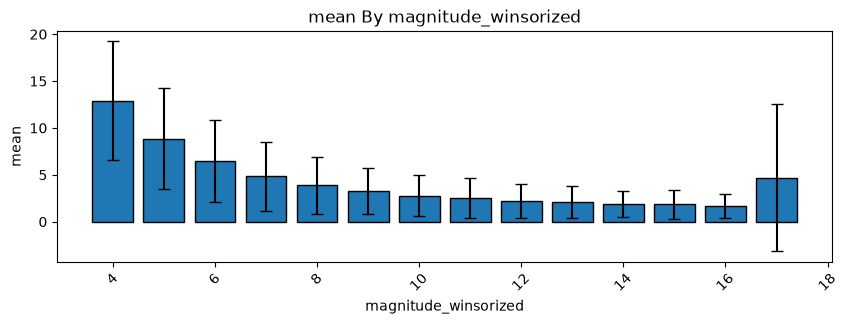

In [8]:
print("Daily Average Legs >= 4 Points:",df_legs_4P.groupby('date').size().mean())
print("Daily Standard Deviation of Legs >= 4 Points:",df_legs_4P.groupby('date').size().std())
print("Daily Average Pecentge of Legs >= 4 Points Out of All Legs:",df_legs_4P.groupby('date').size().mean()/df_legs.groupby('date').size().mean()*100,"%")

df_1 = df_legs_4P.groupby(['contract','date','magnitude_winsorized'],as_index=False).size()
df_1 = utils.descriptive_groupby(df_1,'magnitude_winsorized','size')
utils.bar_chart(df_1,'magnitude_winsorized','mean',yerror=df_1['std'])

In [9]:
# How long do legs >= 4 points last?

Overall Average Duration Of Legs >= 4 Points: 3.3363585523687784
Overall Standard Deviation Duration of Legs >= 4 Points: 1.8401993982077967


,magnitude_winsorized,mean,std
0,4.0,2.760385,1.570835
1,5.0,3.030627,1.666148
2,6.0,3.243396,1.729158
3,7.0,3.451908,1.808536
4,8.0,3.665266,1.838824
5,9.0,3.821833,1.880246
6,10.0,3.958084,1.926760
7,11.0,4.072759,1.949554
8,12.0,4.142750,1.967571
9,13.0,4.284538,1.964080


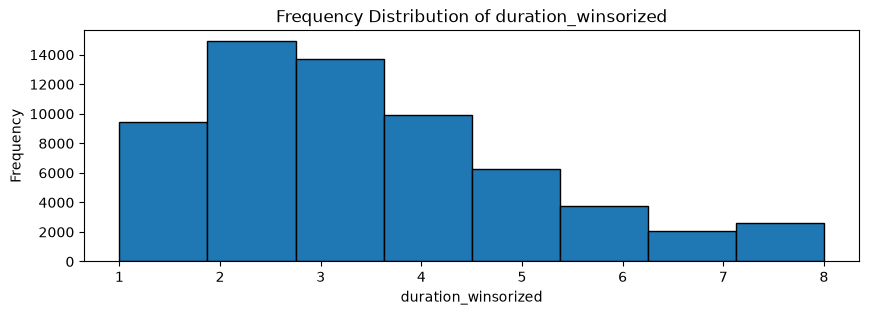

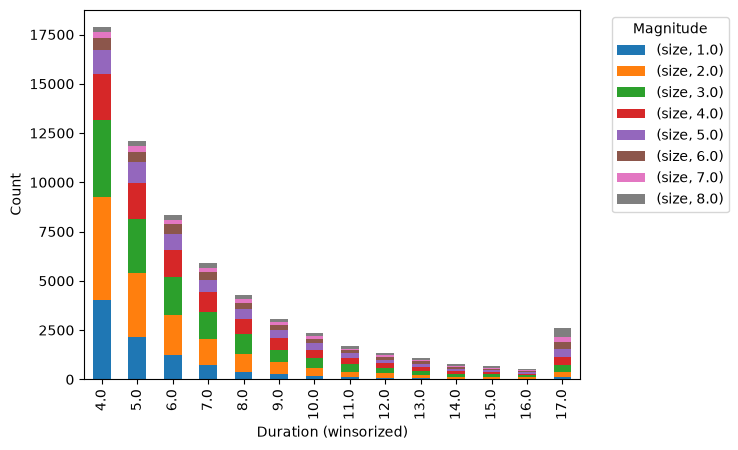

In [10]:
print("Overall Average Duration Of Legs >= 4 Points:",df_legs_4P['duration_winsorized'].mean())
print("Overall Standard Deviation Duration of Legs >= 4 Points:",df_legs_4P['duration_winsorized'].std())
display(utils.descriptive_groupby(df_legs_4P,'magnitude_winsorized','duration_winsorized')[['magnitude_winsorized','mean','std']])

utils.frequency_hist(df_legs_4P,'duration_winsorized',8)

df_2 = df_legs_4P.groupby(['magnitude_winsorized','duration_winsorized'],as_index=False)
count_pivot_2 = df_2.size().pivot(index='magnitude_winsorized', columns='duration_winsorized').fillna(0)
count_pivot_2.plot(kind='bar', stacked=True)
plt.xlabel('Duration (winsorized)')
plt.ylabel('Count')
plt.legend(title='Magnitude',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [11]:
# What is the drawdown of legs >= 4 points?

Average Drawdown of Legs >= 4 points: 0.8012582887273308
Standard Deviation of Drawdown of Legs >= 4 points: 0.8443357585076947
number of legs with drawdowns > 2: 5422
% of legs with drawdowns > 2: 8.663417751857473 %


,magnitude_winsorized,mean,std
0,4.0,0.693371,0.829976
1,5.0,0.734852,0.844978
2,6.0,0.782391,0.930133
3,7.0,0.819169,0.963634
4,8.0,0.885679,0.991921
5,9.0,0.928247,1.102820
6,10.0,0.984602,1.113830
7,11.0,1.076979,1.221205
8,12.0,1.032682,1.154862
9,13.0,1.155306,1.293988


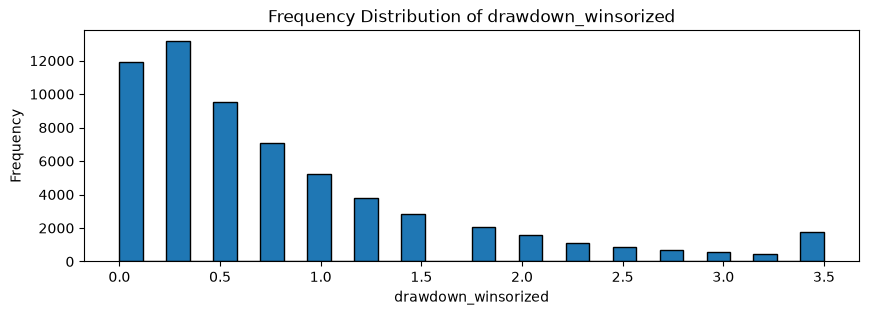

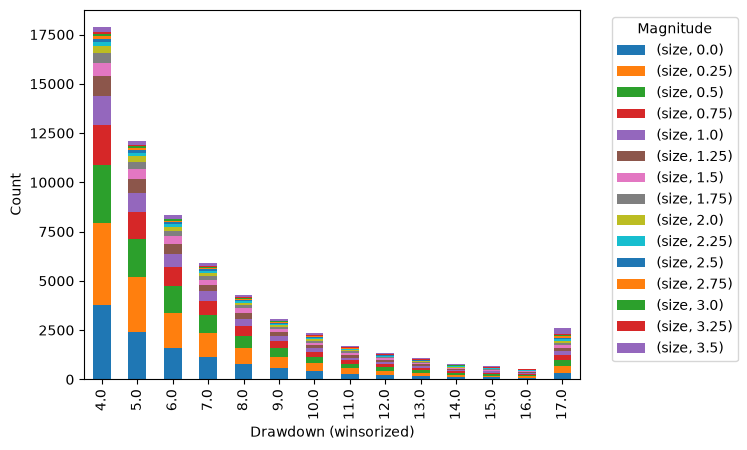

In [12]:
print("Average Drawdown of Legs >= 4 points:", df_legs_4P['drawdown_winsorized'].mean())
print("Standard Deviation of Drawdown of Legs >= 4 points:", df_legs_4P['drawdown_winsorized'].std())

print("number of legs with drawdowns > 2:",len(df_legs_4P[df_legs_4P['drawdown'] > 2]))
print("% of legs with drawdowns > 2:",len(df_legs_4P[df_legs_4P['drawdown'] > 2])/len(df_legs_4P)*100,'%')

display(utils.descriptive_groupby(df_legs_4P,'magnitude_winsorized','drawdown')[['magnitude_winsorized','mean','std']])

utils.frequency_hist(df_legs_4P,'drawdown_winsorized',30)

df_3 = df_legs_4P.groupby(['magnitude_winsorized','drawdown_winsorized'],as_index=False)
count_pivot_3 = df_3.size().pivot(index='magnitude_winsorized', columns='drawdown_winsorized').fillna(0)
count_pivot_3.plot(kind='bar', stacked=True)
plt.xlabel('Drawdown (winsorized)')
plt.ylabel('Count')
plt.legend(title='Magnitude',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [13]:
# When do legs >= 4 points occur most?

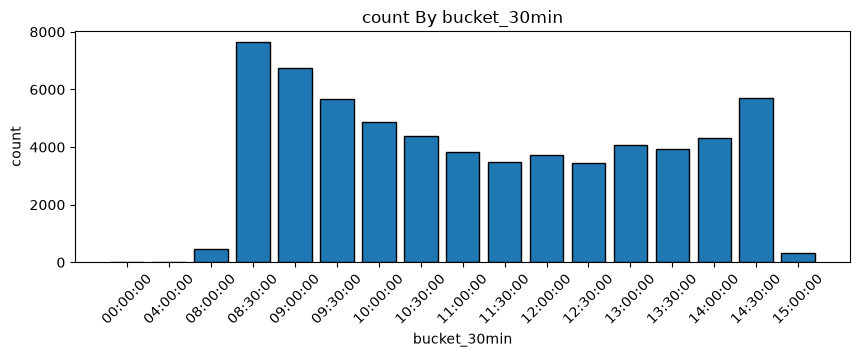

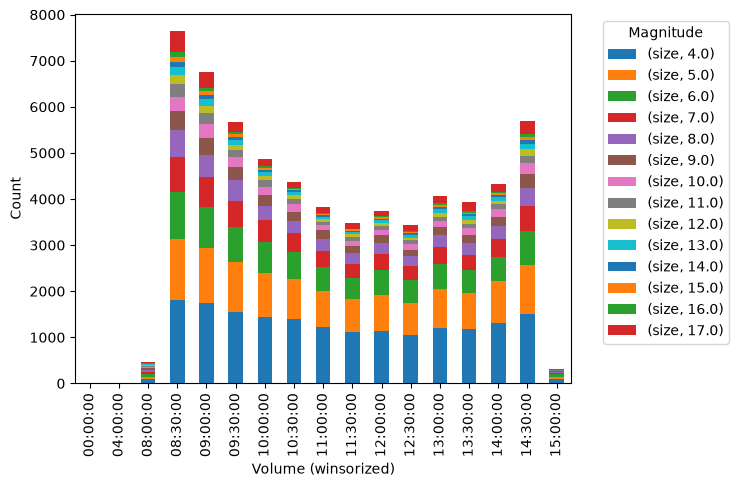

In [14]:
df_4 = utils.descriptive_groupby(df_legs_4P,'bucket_30min','magnitude_winsorized')
df_4['bucket_30min']=df_4['bucket_30min'].astype(str)
utils.bar_chart(df_4,'bucket_30min','count')

df_5 = df_legs_4P.groupby(['bucket_30min','magnitude_winsorized'],as_index=False)

count_pivot_5 = df_5.size().pivot(index='bucket_30min', columns='magnitude_winsorized').fillna(0)
count_pivot_5.plot(kind='bar', stacked=True)
plt.xlabel('Volume (winsorized)')
plt.ylabel('Count')
plt.legend(title='Magnitude',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [15]:
# What is the volume of legs >= 4 points?

Average Volume of Legs >= 4 points: 14112.142138212028
Standard Deviation of Volume of Legs >= 4 points: 9736.94828585343


,magnitude_winsorized,mean,std
0,4.0,9158.732997,6027.843779
1,5.0,11017.700624,6686.058360
2,6.0,12966.528722,7864.441236
3,7.0,14686.869116,8316.791880
4,8.0,16578.126139,9022.230784
5,9.0,18108.706233,9441.939430
6,10.0,19518.820402,9974.212289
7,11.0,20761.387101,10334.161179
8,12.0,21850.848159,10775.757313
9,13.0,23377.559835,10772.717865


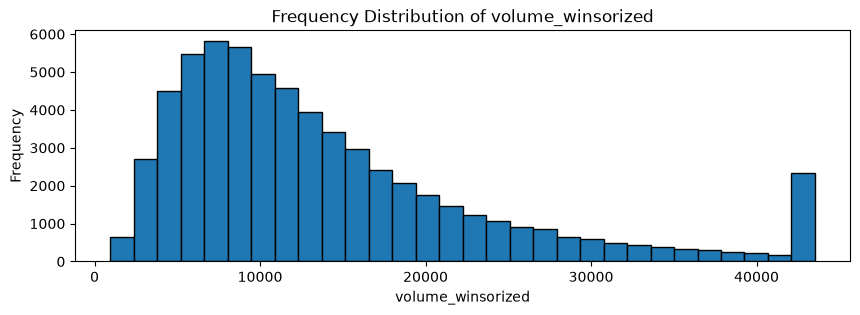

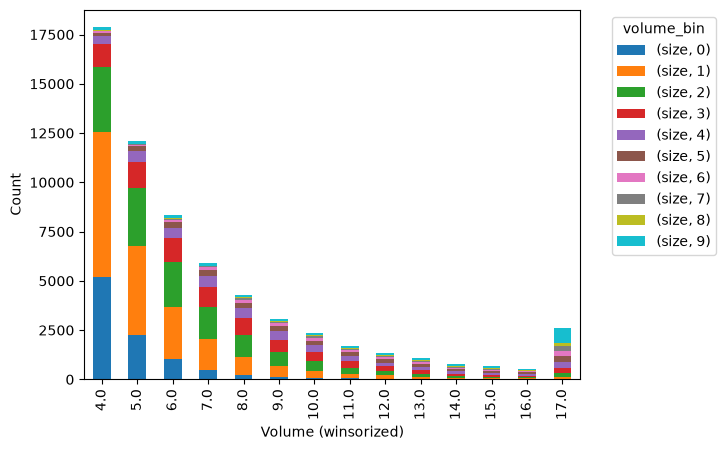

['958.0-5688.113333333323', '5688.113333333323-10418.226666666646', '10418.226666666646-15148.339999999967', '15148.339999999967-19878.45333333329', '19878.45333333329-24608.566666666615', '24608.566666666615-29338.679999999935', '29338.679999999935-34068.79333333326', '34068.79333333326-38798.90666666658', '38798.90666666658-43529.0199999999']


In [19]:
print("Average Volume of Legs >= 4 points:", df_legs_4P['volume_winsorized'].mean())
print("Standard Deviation of Volume of Legs >= 4 points:", df_legs_4P['volume_winsorized'].std())

counts, volume_bins = np.histogram(df_legs_4P['volume_winsorized'], bins=9)

display(utils.descriptive_groupby(df_legs_4P,'magnitude_winsorized','volume_winsorized')[['magnitude_winsorized','mean','std']])

utils.frequency_hist(df_legs_4P,'volume_winsorized',30)

df_legs_4P['volume_bin'] = np.digitize(df_legs_4P['volume_winsorized'],volume_bins)-1
df_6 = df_legs_4P.groupby(['magnitude_winsorized','volume_bin'],as_index=False)

count_pivot_6 = df_6.size().pivot(index='magnitude_winsorized', columns='volume_bin').fillna(0)
count_pivot_6.plot(kind='bar', stacked=True)

plt.xlabel('Volume (winsorized)')
plt.ylabel('Count')
plt.legend(title='volume_bin',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

bin_labels = [f'{volume_bins[i]}-{volume_bins[i+1]}' for i in range(len(volume_bins)-1)]
print(bin_labels)